In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin1', encoding_errors='ignore')


In [3]:
# df.info()

print(df.isna().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


    Region      Sales
0  Central  501239.89
1     East  678781.24
2    South  391721.90
3     West  725457.82


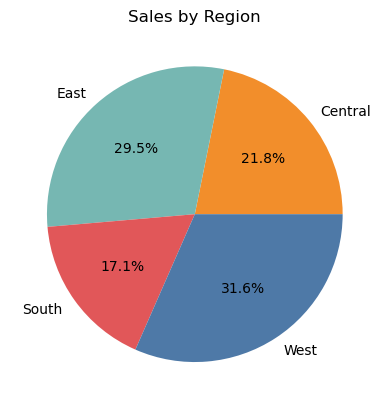

In [4]:
region_sales_df = df.groupby('Region', as_index=False)['Sales'].sum()
region_sales_df = region_sales_df.reset_index(drop=True)
region_sales_df['Sales'] = region_sales_df['Sales'].round(2)
print(region_sales_df)

plt.pie(
    region_sales_df['Sales'],                  
    labels=region_sales_df['Region'],          
    autopct='%1.1f%%',
    colors = ['#f28e2b', '#76b7b2','#e15759','#4e79a7']
)
plt.title("Sales by Region")
plt.show()



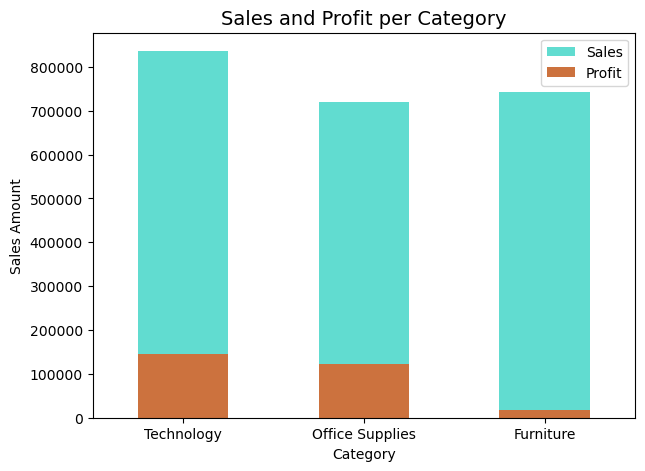

In [16]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=category_analysis.reset_index(),
    x='Category',
    y='Sales',
    color="#4df0e0cd",
    label='Sales',
    width=0.5 
)

sns.barplot(
    data=category_analysis.reset_index(),
    x='Category',
    y='Profit',
    color="#e46c26d4",
    label='Profit',
    width=0.5
)

plt.title('Sales and Profit per Category', fontsize=14)
plt.ylabel('Sales Amount')
plt.legend()
plt.show()


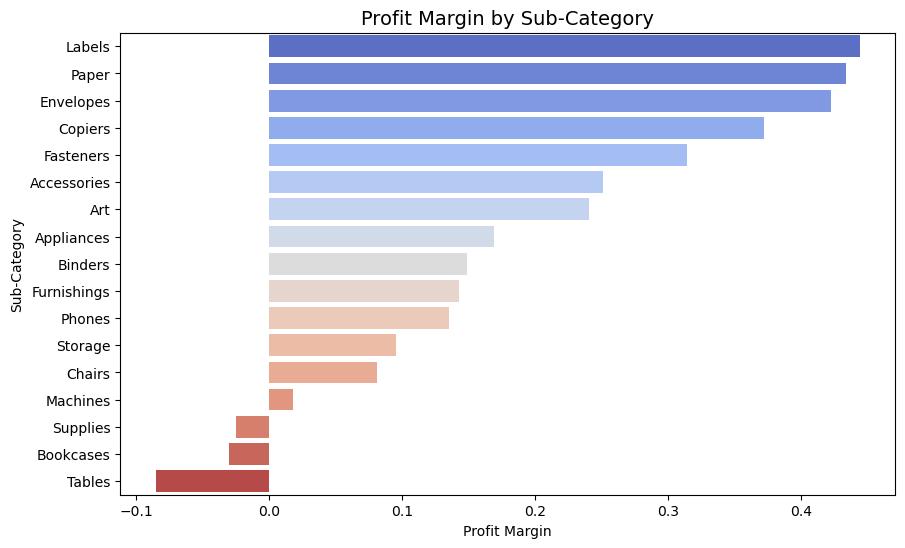

In [20]:
# Product Profitability Analysis 
# 1. Calculate Profit Margin
subcat_sum = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()

subcat_sum['Profit_Margin'] = subcat_sum['Profit'] / subcat_sum['Sales']
subcat_margin = subcat_sum.sort_values('Profit_Margin', ascending=False).reset_index()

# 2. Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    data=subcat_margin,
    x='Profit_Margin',
    y='Sub-Category',
    hue='Sub-Category',
    palette='coolwarm',
    legend=False
)

plt.title("Profit Margin by Sub-Category", fontsize=14)
plt.xlabel("Profit Margin")
plt.show()

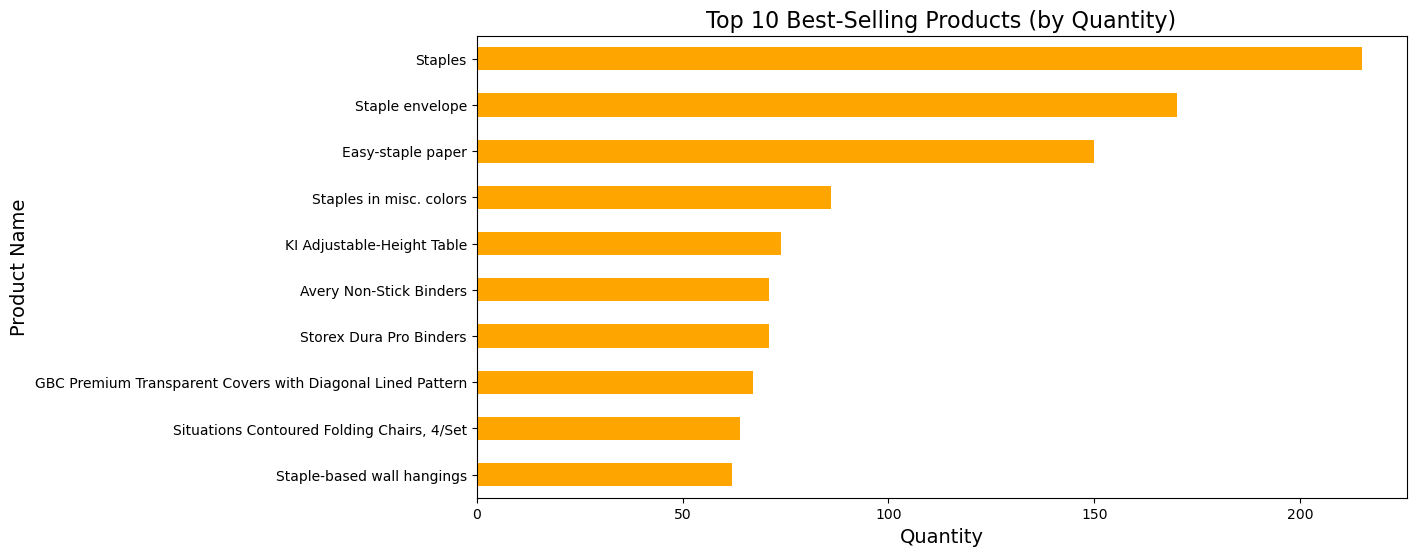

In [13]:
top_products_quantity = (
    df.groupby('Product Name')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products_quantity.plot(kind='barh', color='orange')
plt.title('Top 10 Best-Selling Products (by Quantity)', fontsize=16)
plt.xlabel('Quantity', fontsize=14)
plt.ylabel('Product Name', fontsize=14)
plt.gca().invert_yaxis()
plt.show()


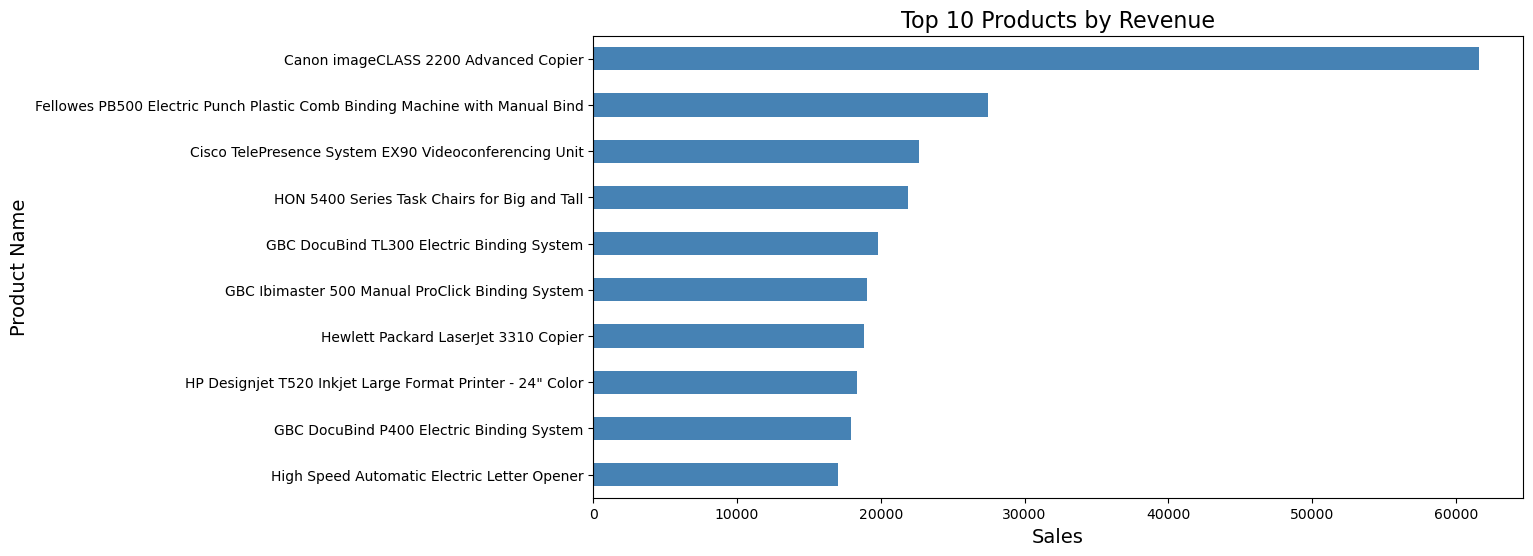

In [15]:
top_products_sales = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products_sales.plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Sales', fontsize=14)
plt.ylabel('Product Name', fontsize=14)
plt.gca().invert_yaxis()
plt.show()


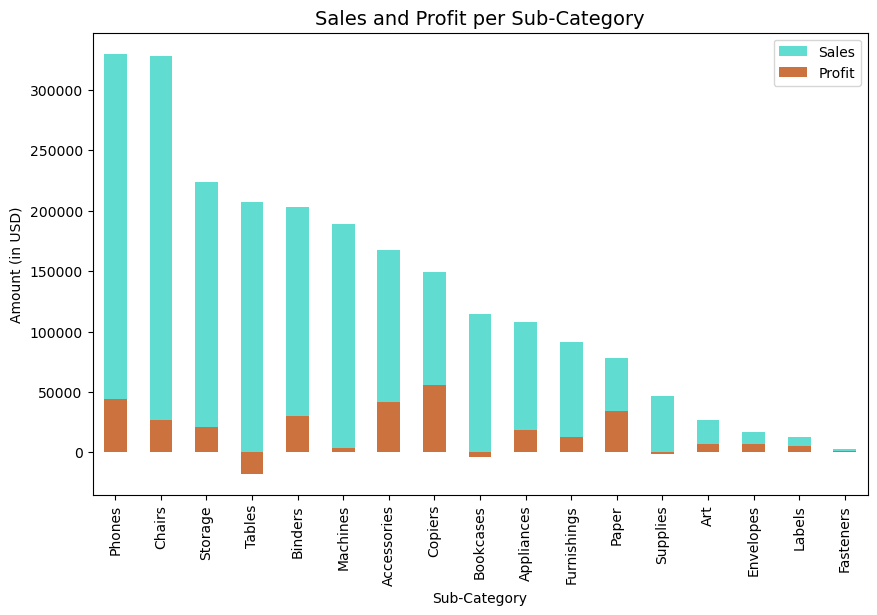

In [ ]:
# Calculate Sales and Profit for each Sub-Category
subcat_analysis = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()

# Sort Sub-Categories by Sales 
subcat_analysis = subcat_analysis.sort_values('Sales', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=subcat_analysis,
    x='Sub-Category',
    y='Sales',
    color="#4df0e0cd",
    label='Sales',
    width=0.5 
)

sns.barplot(
    data=subcat_analysis,
    x='Sub-Category',
    y='Profit',
    color="#e46c26d4",
    label='Profit',
    width=0.5
)

plt.title('Sales and Profit per Sub-Category', fontsize=14)
plt.ylabel('Amount (in USD)')
plt.xticks(rotation=90)  
plt.legend()

plt.show()


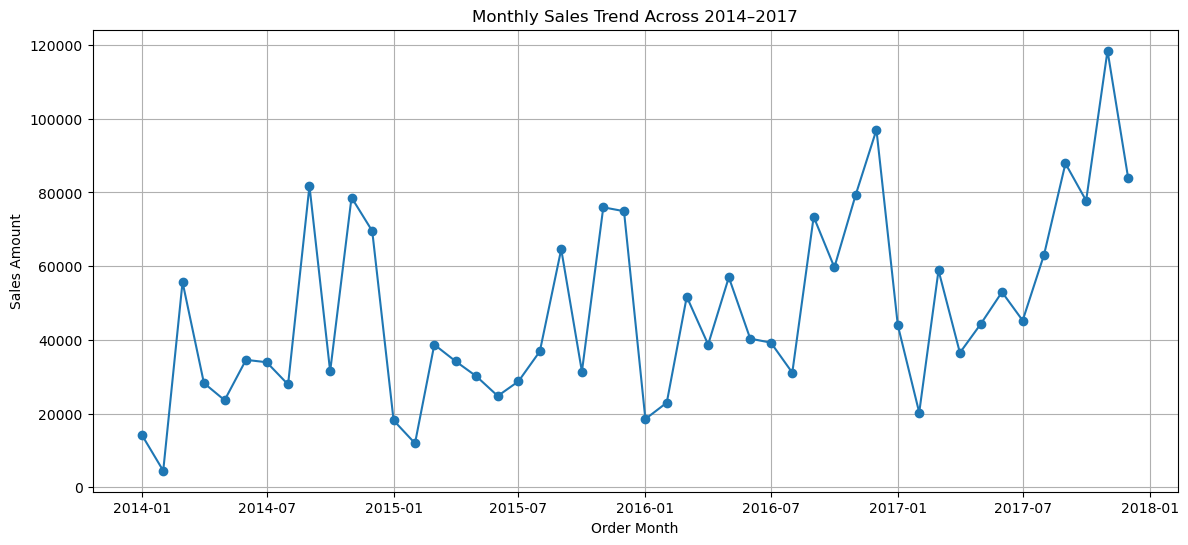

In [ ]:
# Convert Order Date column to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Convert Order Date to a standardized monthly timestamp
df['Order Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

monthly_sales = df.groupby('Order Month')['Sales'].sum().sort_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend Across 2014–2017')
plt.xlabel('Order Month')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.show()
